In [ ]:
!pip -q install shap xgboost seaborn

import pandas as pd, numpy as np, glob, os, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from scipy.stats import spearmanr

from google.colab import drive
drive.mount('/content/drive')

hits = glob.glob('/content/drive/MyDrive/**/Copy of Communication*', recursive=True)
DATA_DIR = os.path.dirname(hits[0]); print('Data folder:', DATA_DIR)
def p(fname): return os.path.join(DATA_DIR, fname)

DEMO_COLS = ['Age','Generation','Years Working','Experience','Studying or Employed','Level Of Seniority','Industry']
ID_COLS = ['No','Participant','Client_Source']
TIER_A = ['Succint Communication','Critical Thinking','Emotional Intelligence','Resilience','Flexibility & Adaptability','Growth Mindset','Collaborative Mindset']
CORE_MAP = {
 'Communication':['Active Listening','Succint Communication','Asking Questions','Asking For Feedback','Presentation Skills'],
 'Decision Making':['Initiative','Critical Thinking','Negotiation','Conflict Resolution'],
 'EQ':['Emotional Intelligence','Readiness for Change','Resilience','Self Motivation'],
 'Leadership':['Effective Client Management','Influencing Others','Managing Upwards','Performance Management','Team Leadership'],
 'Self Management':['Dealing with Senior Staff','First Impressions','Flexibility & Adaptability','Growth Mindset','Responding to Critical Feedback'],
 'Teamwork':['Accountability','Collaborative Mindset','Networking','Working in a Team'],
 'Time Management':['Delegation','Goal Setting','Managing Time and Priorities','Professional Behaviour']}

Mounted at /content/drive
Data folder: /content/drive/MyDrive/Data_Human Skills Insights Report_2025


In [ ]:
df = pd.read_csv(p('LEVRA_Master_Data_2026.csv')); df.columns=[c.strip() for c in df.columns]
skill_cols = [c for c in df.columns if c not in ID_COLS + DEMO_COLS]
print('Raw rows:', len(df), '| Unique participants:', df['Participant'].nunique())

# demographic values sometimes disagree across a learner's rows -> flag, then take the most common
inconsistent = df.groupby('Participant')[DEMO_COLS].nunique()
print('Learners with inconsistent demographics across rows:', len(inconsistent[(inconsistent>1).any(axis=1)]))

df[skill_cols] = df[skill_cols].apply(pd.to_numeric, errors='coerce')   # text "Null" -> real NaN
def mode_or_nan(s):
    s=s.dropna(); return s.mode().iloc[0] if len(s) else np.nan
demo_c  = df.groupby('Participant')[DEMO_COLS].agg(mode_or_nan)                                   # mode for demographics
skill_c = df.groupby('Participant')[skill_cols].agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)  # first non-null per skill
master  = pd.concat([demo_c, skill_c], axis=1).reset_index()
print('Consolidated shape:', master.shape, '(expect 160 x 39)')

Raw rows: 1049 | Unique participants: 160
Learners with inconsistent demographics across rows: 83
Consolidated shape: (160, 39) (expect 160 x 39)


In [ ]:
print('Team Leadership vs Effective Client Mgmt match BEFORE:', round((master['Team Leadership']==master['Effective Client Management']).mean(),3))
lead_fix = pd.read_excel(p('Copy of Leadership_Data_Percentages Upload.xlsx')); lead_fix.columns=[c.strip() for c in lead_fix.columns]
lead_fix['Team Leadership'] = pd.to_numeric(lead_fix['Team Leadership'], errors='coerce')
master['Team Leadership'] = master['Participant'].map(lead_fix.set_index('Participant')['Team Leadership'])
print('Match AFTER (want ~0.006, not 0.75):', round((master['Team Leadership']==master['Effective Client Management']).mean(),3))

Team Leadership vs Effective Client Mgmt match BEFORE: 0.75
Match AFTER (want ~0.006, not 0.75): 0.006


=== BEFORE ===
Missingness: 31.0% | learners affected: 86/160
Structural blocks: 101 | Partial gaps: 434

=== Imputation comparison (lower MAE = better) ===
  Mean             MAE 0.1450
  Median           MAE 0.1459
  KNN (k=10)       MAE 0.1379
  Iterative (RF)   MAE 0.1368
-> Best: Iterative (RF) (exploits inter-skill correlations). Mode excluded (not valid for continuous scores).

=== AFTER (RF-imputed modelling copy) === Missingness: 0.0%


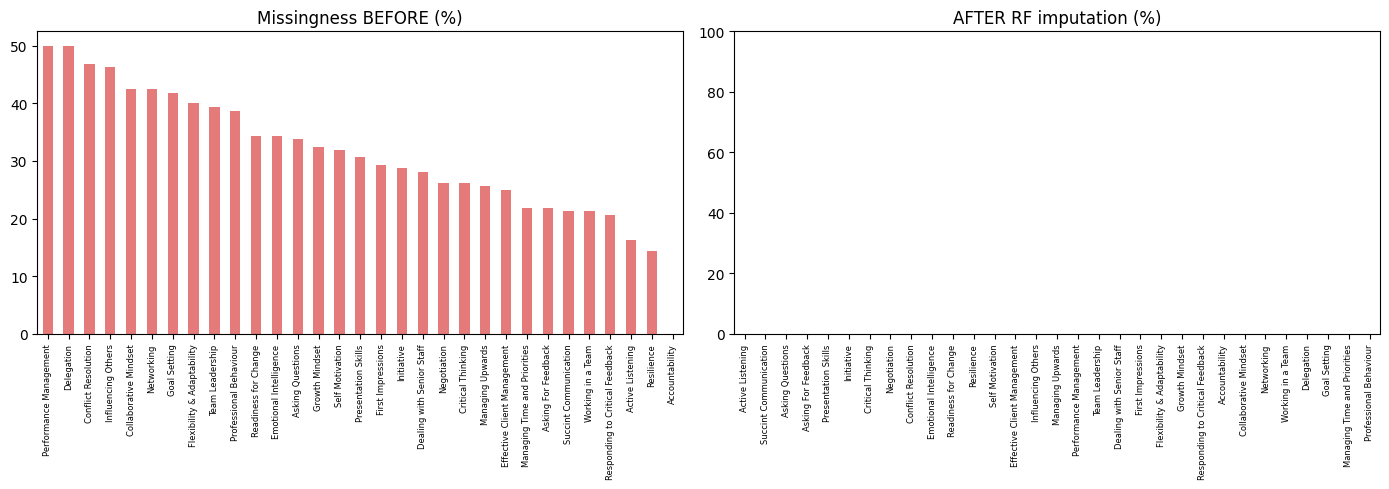

Saved raw (for ARS) + RF-imputed (for modelling).


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor

skills=[c for c in master.columns if c not in ['No','Participant']+DEMO_COLS]
for c in skills: master[c]=pd.to_numeric(master[c],errors='coerce')

# BEFORE
print('=== BEFORE ==='); print(f'Missingness: {master[skills].isna().mean().mean()*100:.1f}% | learners affected: {master[skills].isna().any(axis=1).sum()}/{len(master)}')

# DIAGNOSE structural (whole test skipped) vs partial (one sub-score gap)
structural=partial=0
for core,subs in CORE_MAP.items():
    subs=[s for s in subs if s in master.columns]; b=master[subs].isna()
    structural+=b.all(axis=1).sum(); partial+=(b.any(axis=1)&~b.all(axis=1)).sum()
print(f'Structural blocks: {structural} | Partial gaps: {partial}')

# COMPARE methods by masked-value recovery (hide 15% of KNOWN values, see who recovers them best)
np.random.seed(42); X=master[skills]
idx=np.argwhere(X.notna().values); np.random.shuffle(idx); cells=idx[:int(len(idx)*0.15)]
Xm=X.copy().values.astype(float); truth=np.array([Xm[i,j] for i,j in cells])
for i,j in cells: Xm[i,j]=np.nan
methods={'Mean':SimpleImputer(strategy='mean'),'Median':SimpleImputer(strategy='median'),
 'KNN (k=10)':KNNImputer(n_neighbors=10),
 'Iterative (RF)':IterativeImputer(estimator=RandomForestRegressor(n_estimators=50,random_state=42),max_iter=5,random_state=42)}
print('\n=== Imputation comparison (lower MAE = better) ===')
scores={}
for name,imp in methods.items():
    f=imp.fit_transform(Xm); pred=np.array([f[i,j] for i,j in cells]); scores[name]=np.mean(np.abs(pred-truth))
    print(f'  {name:16s} MAE {scores[name]:.4f}')
best=min(scores,key=scores.get); print(f'-> Best: {best} (exploits inter-skill correlations). Mode excluded (not valid for continuous scores).')

# APPLY: RF imputation for a MODELLING copy; keep RAW (NaN) for ARS scoring
master_raw=master.copy()
rf_imp=IterativeImputer(estimator=RandomForestRegressor(n_estimators=50,random_state=42),max_iter=5,random_state=42)
master_imp=master.copy(); master_imp[skills]=rf_imp.fit_transform(master[skills])
print(f'\n=== AFTER (RF-imputed modelling copy) === Missingness: {master_imp[skills].isna().mean().mean()*100:.1f}%')

# BEFORE/AFTER visual
fig,ax=plt.subplots(1,2,figsize=(14,5))
(master_raw[skills].isna().mean()*100).sort_values(ascending=False).plot(kind='bar',ax=ax[0],color='#e57a7a'); ax[0].set_title('Missingness BEFORE (%)'); ax[0].tick_params(axis='x',labelsize=6)
(master_imp[skills].isna().mean()*100).plot(kind='bar',ax=ax[1],color='#5fd0b0'); ax[1].set_title('AFTER RF imputation (%)'); ax[1].set_ylim(0,100); ax[1].tick_params(axis='x',labelsize=6)
plt.tight_layout(); plt.show()

master_raw.to_csv(p('LEVRA_Master_Consolidated.csv'),index=False)
master_imp.to_csv(p('LEVRA_Master_Imputed.csv'),index=False)
master=master_raw
print('Saved raw (for ARS) + RF-imputed (for modelling).')

In [ ]:
skill_files={'Communication':'Copy of Communication_Data_Percentages Upload.xlsx','Decision Making':'Copy of Decision Making_Data_Percentages Upload.xlsx','EQ':'Copy of EQ_Data_Percentages Upload.xlsx','Leadership':'Copy of Leadership_Data_Percentages Upload.xlsx','Self Management':'Copy of Self Management_Data_Percentages Upload.xlsx','Teamwork':'Copy of Teamwork_Data_Percentages Upload.xlsx','Time Management':'Copy of Time Management_Data_Percentages Upload.xlsx'}
profiles={}
print(f"{'File':16s}{'n':>4s}{'%GenZ':>7s}{'mean':>8s}{'internal_r':>12s}")
for name,f in skill_files.items():
    d=pd.read_excel(p(f)); d.columns=[c.strip() for c in d.columns]
    sc=[c for c in d.columns if c not in ['No','Participant']+DEMO_COLS]; d[sc]=d[sc].apply(pd.to_numeric,errors='coerce'); profiles[name]=d
    cr=d[sc].corr(); mk=~np.eye(len(cr),dtype=bool)
    print(f'{name:16s}{d["Participant"].nunique():>4d}{(d["Generation"]=="Gen Z").mean()*100:>6.0f}%{d[sc].mean().mean():>8.3f}{cr.values[mk].mean():>12.3f}')
groups=[d[[c for c in d.columns if c not in ["No","Participant"]+DEMO_COLS]].mean(axis=1).dropna().values for d in profiles.values()]
H,pv=stats.kruskal(*groups); print(f'\nKruskal-Wallis across files: H={H:.1f}, p={pv:.4f} (cohorts comparable on demographics; scores differ by skill domain, as expected)')

File               n  %GenZ    mean  internal_r
Communication    160    81%   0.645       0.275
Decision Making  139    82%   0.717       0.296
EQ               137    82%   0.650       0.408
Leadership       153    82%   0.617       0.254
Self Management  147    86%   0.629       0.261
Teamwork         160    82%   0.625       0.135
Time Management  153    84%   0.626       0.183

Kruskal-Wallis across files: H=87.0, p=0.0000 (cohorts comparable on demographics; scores differ by skill domain, as expected)


160 learners x 31 skills


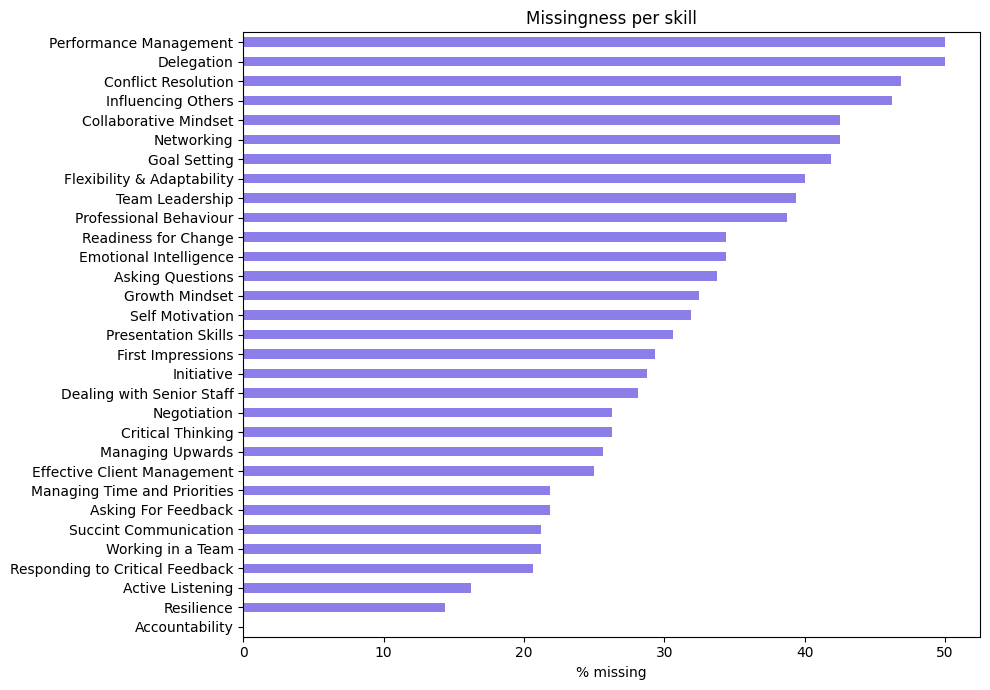

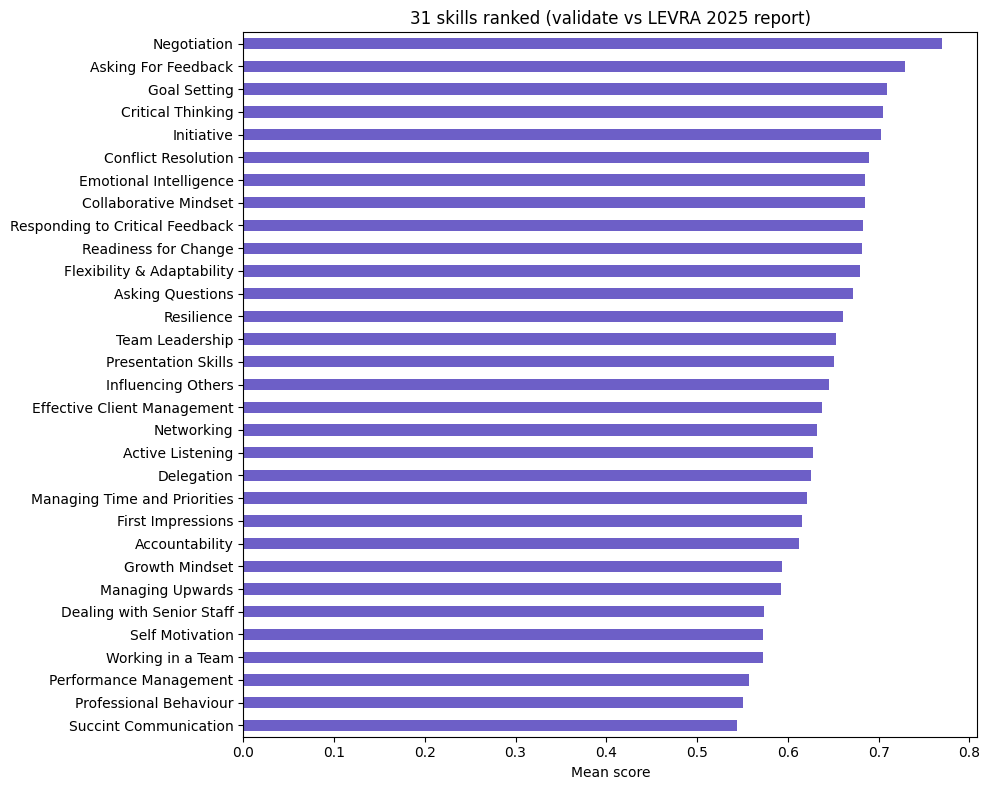

Highest: {'Goal Setting': 0.709, 'Asking For Feedback': 0.729, 'Negotiation': 0.77} | Lowest: {'Succint Communication': 0.544, 'Professional Behaviour': 0.55, 'Performance Management': 0.558}


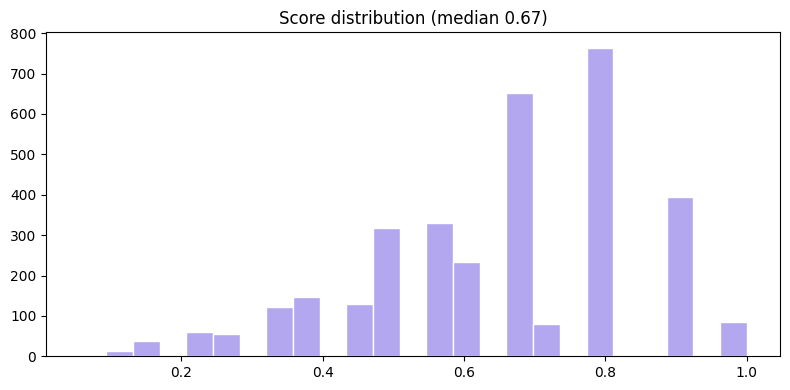

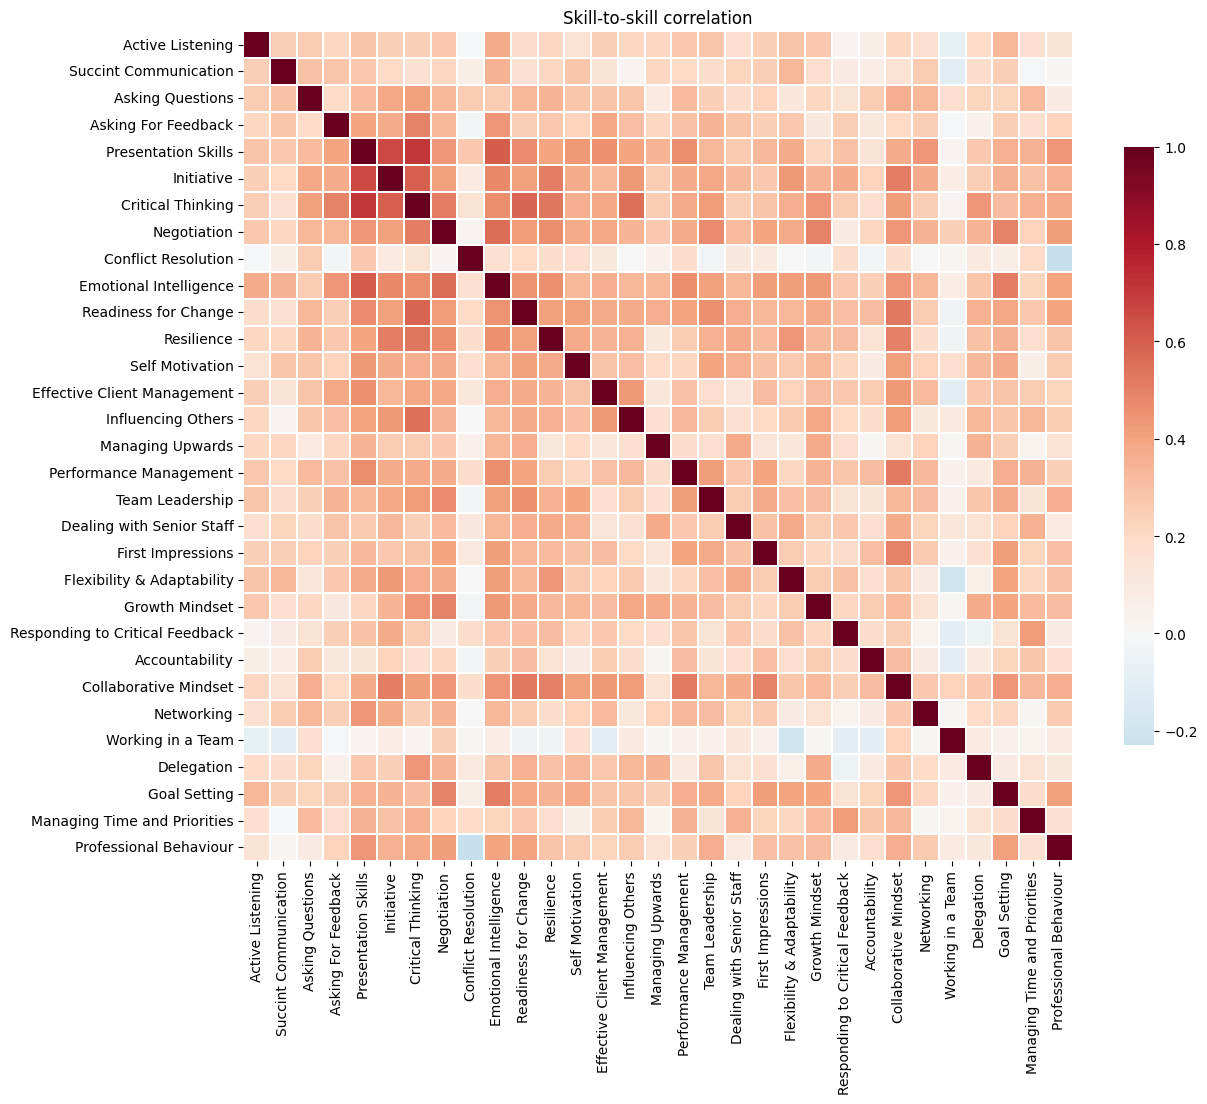


=== overall by Industry ===
             mean  count
Industry                
Consulting  0.704     16
Law         0.687     33
Other       0.669     35
Media       0.646     11
Education   0.639     25
Auditing    0.619      6
Technology  0.584     20

=== overall by Generation ===
             mean  count
Generation              
Other       0.655     29
Gen Z       0.653    131

=== overall by Level Of Seniority ===
                     mean  count
Level Of Seniority              
Graduate            0.699     10
Trainee             0.675     39
Assisstant Manager  0.659     10
Other               0.659     21
Manager             0.658     14
Apprentice          0.648      7
Student             0.623     54

Charts saved to /content/drive/MyDrive/LEVRA_EDA_charts


In [ ]:
import os
FIGDIR='/content/drive/MyDrive/LEVRA_EDA_charts'; os.makedirs(FIGDIR,exist_ok=True)
skills=[c for c in master.columns if c not in ['No','Participant','high_missing']+DEMO_COLS]
print(f'{master.shape[0]} learners x {len(skills)} skills')

miss=(master[skills].isna().mean()*100).sort_values(ascending=False)
fig=plt.figure(figsize=(10,7)); miss.plot(kind='barh',color='#8b7ee8'); plt.gca().invert_yaxis(); plt.xlabel('% missing'); plt.title('Missingness per skill'); plt.tight_layout()
fig.savefig(f'{FIGDIR}/01_missingness.png',dpi=150,bbox_inches='tight'); plt.show(); plt.close(fig)

ranking=master[skills].mean().sort_values()
fig=plt.figure(figsize=(10,8)); ranking.plot(kind='barh',color='#6d5fc7'); plt.xlabel('Mean score'); plt.title('31 skills ranked (validate vs LEVRA 2025 report)'); plt.tight_layout()
fig.savefig(f'{FIGDIR}/02_skill_ranking.png',dpi=150,bbox_inches='tight'); plt.show(); plt.close(fig)
print('Highest:',ranking.tail(3).round(3).to_dict(),'| Lowest:',ranking.head(3).round(3).to_dict())

allv=master[skills].values.flatten(); allv=allv[~np.isnan(allv)]
fig=plt.figure(figsize=(8,4)); plt.hist(allv,bins=25,color='#b3a7f0',edgecolor='white'); plt.title(f'Score distribution (median {np.median(allv):.2f})'); plt.tight_layout()
fig.savefig(f'{FIGDIR}/03_distribution.png',dpi=150,bbox_inches='tight'); plt.show(); plt.close(fig)

fig=plt.figure(figsize=(13,11)); sns.heatmap(master[skills].corr(min_periods=20),cmap='RdBu_r',center=0,square=True,linewidths=0.3,cbar_kws={'shrink':0.7}); plt.title('Skill-to-skill correlation'); plt.tight_layout()
fig.savefig(f'{FIGDIR}/04_correlation.png',dpi=150,bbox_inches='tight'); plt.show(); plt.close(fig)

master['overall']=master[skills].mean(axis=1)
for col in ['Industry','Generation','Level Of Seniority']:
    g=master.groupby(col)['overall'].agg(['mean','count']).round(3); g=g[g['count']>=5].sort_values('mean',ascending=False); print(f'\n=== overall by {col} ==='); print(g.to_string())
print(f'\nCharts saved to {FIGDIR}')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

X=master[TIER_A].apply(pd.to_numeric,errors='coerce')
Xi=pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X),columns=TIER_A)  # PCA needs complete data
def cronbach(f):
    k=f.shape[1]; return (k/(k-1))*(1-f.var(ddof=1).sum()/f.sum(axis=1).var(ddof=1))
print('Cronbach alpha (>0.7 = coherent scale):', round(cronbach(Xi),3))

pca=PCA().fit(StandardScaler().fit_transform(Xi))
pc1=pd.Series(pca.components_[0],index=TIER_A)
if pc1.mean()<0: pc1=-pc1
w_pca=pc1/pc1.sum(); w_equal=pd.Series(1/len(TIER_A),index=TIER_A)
print('PC1 variance captured:', round(pca.explained_variance_ratio_[0],3))
print(pd.DataFrame({'PCA weight':w_pca,'Equal weight':w_equal}).round(3).sort_values('PCA weight',ascending=False))

def ars(row,w):
    v=row[TIER_A]; m=v.notna()
    if m.sum()==0: return np.nan
    ww=w[m.values]/w[m.values].sum(); return (v[m].values*ww.values).sum()   # renormalise over available skills
master['ARS_pca']=X.apply(lambda r: ars(r,w_pca),axis=1)
master['ARS_equal']=X.apply(lambda r: ars(r,w_equal),axis=1)
v=master[['ARS_pca','ARS_equal']].dropna()
print('ARS mean:',round(master['ARS_pca'].mean(),3),'| robustness (PCA vs Equal Spearman):',round(spearmanr(v['ARS_pca'],v['ARS_equal'])[0],3))
master['ARS_tier']=pd.qcut(master['ARS_pca'],3,labels=['Emerging','Developing','Ready'])
master.to_csv(p('LEVRA_Master_ARS.csv'),index=False)
print('Tiers:',master['ARS_tier'].value_counts().to_dict())

Cronbach alpha (>0.7 = coherent scale): 0.762
PC1 variance captured: 0.417
                            PCA weight  Equal weight
Emotional Intelligence           0.170         0.143
Resilience                       0.165         0.143
Critical Thinking                0.163         0.143
Flexibility & Adaptability       0.138         0.143
Growth Mindset                   0.136         0.143
Collaborative Mindset            0.130         0.143
Succint Communication            0.098         0.143
ARS mean: 0.661 | robustness (PCA vs Equal Spearman): 0.992
Tiers: {'Emerging': 53, 'Developing': 53, 'Ready': 53}


In [ ]:
print('=== Fairness (Kruskal-Wallis) ===')
for col in ['Generation','Industry','Level Of Seniority']:
    sub=master[[col,'ARS_pca']].dropna(); grp=[g['ARS_pca'].values for _,g in sub.groupby(col) if len(g)>=8]
    if len(grp)<2: continue
    H,pv=stats.kruskal(*grp); print(f'\n{col}: p={pv:.3f}','<-- SIGNIFICANT' if pv<0.05 else '(no sig diff)')
    mm=sub.groupby(col)['ARS_pca'].agg(['mean','count']).round(3); print(mm[mm['count']>=8].sort_values('mean',ascending=False).to_string())

=== Fairness (Kruskal-Wallis) ===

Generation: p=0.906 (no sig diff)
             mean  count
Generation              
Gen Z       0.662    130
Other       0.658     29

Industry: p=0.001 <-- SIGNIFICANT
             mean  count
Industry                
Law         0.723     33
Consulting  0.707     15
Other       0.686     35
Media       0.641     11
Education   0.635     25
Technology  0.582     20

Level Of Seniority: p=0.074 (no sig diff)
                     mean  count
Level Of Seniority              
Graduate            0.698      9
Trainee             0.698     39
Manager             0.679     14
Other               0.672     21
Assisstant Manager  0.638     10
Student             0.623     54


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap

mdl_df=pd.read_csv(p('LEVRA_Master_Imputed.csv')); mdl_df.columns=[c.strip() for c in mdl_df.columns]
mdl_df=mdl_df.merge(master[['Participant','ARS_tier']],on='Participant',how='left')
non_ars=['Active Listening','Asking Questions','Asking For Feedback','Presentation Skills','Initiative','Negotiation','Conflict Resolution','Readiness for Change','Self Motivation','Effective Client Management','Influencing Others','Managing Upwards','Performance Management','Team Leadership','Dealing with Senior Staff','First Impressions','Responding to Critical Feedback','Accountability','Networking','Working in a Team','Delegation','Goal Setting','Managing Time and Priorities','Professional Behaviour']
feat=mdl_df[non_ars+DEMO_COLS].copy()
for c in non_ars: feat[c]=pd.to_numeric(feat[c],errors='coerce')
for c in ['Age','Generation','Studying or Employed','Level Of Seniority','Industry','Experience']: feat[c]=LabelEncoder().fit_transform(feat[c].astype(str))
feat['Years Working']=pd.to_numeric(feat['Years Working'],errors='coerce')
from sklearn.impute import SimpleImputer
y=mdl_df['ARS_tier']; mask=y.notna(); Xm=feat[mask].reset_index(drop=True); ym=y[mask].reset_index(drop=True)
Xm=pd.DataFrame(SimpleImputer(strategy='median').fit_transform(Xm),columns=Xm.columns); y_enc=LabelEncoder().fit_transform(ym)
cv=StratifiedKFold(5,shuffle=True,random_state=42)
print('=== Model comparison (5-fold CV, driver analysis) ===')
for name,m in {'Logistic':Pipeline([('s',StandardScaler()),('m',LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42))]),'Random Forest':RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_leaf=5,class_weight='balanced',random_state=42),'Gradient Boosting':GradientBoostingClassifier(n_estimators=200,max_depth=3,random_state=42),'XGBoost':XGBClassifier(n_estimators=200,max_depth=3,learning_rate=0.1,subsample=0.9,eval_metric='mlogloss',random_state=42)}.items():
    yy=y_enc if name=='XGBoost' else ym; acc=cross_val_score(m,Xm,yy,cv=cv,scoring='accuracy'); print(f'  {name:20s}: {acc.mean():.3f} ± {acc.std():.3f}')
print(f'  (baseline {1/3:.3f}) -> Random Forest best; chosen for performance + SHAP support')
rf=RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_leaf=5,class_weight='balanced',random_state=42).fit(Xm,ym)
sv=shap.TreeExplainer(rf).shap_values(Xm)
imp=np.mean([np.abs(s).mean(0) for s in sv],axis=0) if isinstance(sv,list) else np.abs(sv).mean(axis=(0,2))
print('\n=== Top 10 drivers of ARS tier (mean |SHAP|) ==='); print(pd.Series(imp,index=Xm.columns).sort_values(ascending=False).head(10).round(4).to_string())

=== Model comparison (5-fold CV, driver analysis) ===
  Logistic            : 0.478 ± 0.067
  Random Forest       : 0.491 ± 0.052
  Gradient Boosting   : 0.497 ± 0.049
  XGBoost             : 0.484 ± 0.095
  (baseline 0.333) -> Random Forest best; chosen for performance + SHAP support

=== Top 10 drivers of ARS tier (mean |SHAP|) ===
Presentation Skills          0.0329
Readiness for Change         0.0326
Negotiation                  0.0276
Initiative                   0.0194
Influencing Others           0.0152
Self Motivation              0.0135
Managing Upwards             0.0132
Dealing with Senior Staff    0.0130
First Impressions            0.0123
Networking                   0.0108


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
demo_feat=master[DEMO_COLS].copy()
for c in ['Age','Generation','Studying or Employed','Level Of Seniority','Industry','Experience']: demo_feat[c]=LabelEncoder().fit_transform(demo_feat[c].astype(str))
demo_feat['Years Working']=pd.to_numeric(demo_feat['Years Working'],errors='coerce'); demo_feat=pd.DataFrame(SimpleImputer(strategy='median').fit_transform(demo_feat),columns=demo_feat.columns)
y=master['ARS_tier']; mask=y.notna()
acc=cross_val_score(RandomForestClassifier(n_estimators=300,max_depth=5,min_samples_leaf=5,class_weight='balanced',random_state=42),demo_feat[mask].reset_index(drop=True),y[mask].reset_index(drop=True),cv=StratifiedKFold(5,shuffle=True,random_state=42),scoring='accuracy')
print(f'Predict ARS tier from DEMOGRAPHICS: acc {acc.mean():.3f} (baseline {1/3:.3f})')
yr=pd.to_numeric(master['ARS_pca'],errors='coerce'); mr=yr.notna()
r2=cross_val_score(RandomForestRegressor(n_estimators=300,max_depth=5,min_samples_leaf=5,random_state=42),demo_feat[mr].reset_index(drop=True),yr[mr].reset_index(drop=True),cv=KFold(5,shuffle=True,random_state=42),scoring='r2')
print(f'Predict ARS score from DEMOGRAPHICS: R² {r2.mean():+.3f}')
print('FINDING: demographics do NOT predict ARS -> readiness is individual, must be measured.')

Predict ARS tier from DEMOGRAPHICS: acc 0.314 (baseline 0.333)
Predict ARS score from DEMOGRAPHICS: R² -0.076
FINDING: demographics do NOT predict ARS -> readiness is individual, must be measured.


In [ ]:
skills=[c for c in master.columns if c not in ['No','Participant','overall','high_missing']+DEMO_COLS and not c.startswith('ARS') and 'tier' not in c.lower()]
print('=== Core-skill means (consistency check vs per-file EDA) ===')
for core,vv in sorted({c:master[s].mean().mean() for c,s in CORE_MAP.items()}.items(),key=lambda x:-x[1]): print(f'  {core:18s} {vv:.3f}')
corr=master[skills].corr(min_periods=20); tA=[s for s in TIER_A if s in corr.columns]; nonA=[s for s in skills if s not in TIER_A]
within=[corr.loc[a,b] for i,a in enumerate(tA) for b in tA[i+1:]]; cross=[corr.loc[a,b] for a in tA for b in nonA if pd.notna(corr.loc[a,b])]
print(f'\nLiterature grouping vs data -> among Tier-A: {np.nanmean(within):.3f} | Tier-A vs others: {np.nanmean(cross):.3f} (within>cross = data echoes literature)')
print('\n=== Hub skills (avg correlation to all others) ==='); print(corr.mean().sort_values(ascending=False).head(5).round(3).to_string())
ars=pd.to_numeric(master['ARS_pca'],errors='coerce')
print('\n=== Skills most correlated with ARS (cross-check vs SHAP) ===');
for s,r in sorted({s:master[s].corr(ars) for s in skills if s not in TIER_A}.items(),key=lambda x:-abs(x[1]))[:6]: print(f'  {r:+.2f}  {s}')

=== Core-skill means (consistency check vs per-file EDA) ===
  Decision Making    0.717
  EQ                 0.650
  Communication      0.645
  Self Management    0.629
  Time Management    0.626
  Teamwork           0.625
  Leadership         0.617

Literature grouping vs data -> among Tier-A: 0.356 | Tier-A vs others: 0.291 (within>cross = data echoes literature)

=== Hub skills (avg correlation to all others) ===
Emotional Intelligence    0.394
Critical Thinking         0.392
Presentation Skills       0.391
Initiative                0.376
Negotiation               0.374

=== Skills most correlated with ARS (cross-check vs SHAP) ===
  +0.64  Negotiation
  +0.63  Initiative
  +0.57  Readiness for Change
  +0.55  Goal Setting
  +0.54  Presentation Skills
  +0.49  Performance Management


In [ ]:
print("="*60); print("PIPELINE A — FINAL RESULTS SUMMARY"); print("="*60)
print(f"""
DATA
  Raw records ................. 1049  ->  160 learners (consolidated)
  Skills ...................... 31 (7 core Human Skills)
  Missingness ................. 31% (mostly within-test gaps)
  Imputation .................. Iterative-RF (best of 4 tested); ARS uses raw

AI READINESS SCORE (ARS)
  Inputs ...................... 7 literature-selected skills
  Reliability (Cronbach a) .... {cronbach(Xi):.3f}  (coherent scale)
  Variance in one factor (PC1)  {pca.explained_variance_ratio_[0]*100:.1f}%
  Mean ARS .................... {master['ARS_pca'].mean():.3f}   Tiers: 53/53/53
  Robustness (PCA vs Equal) ... Spearman {spearmanr(v['ARS_pca'],v['ARS_equal'])[0]:.3f}

FAIRNESS
  Generation .................. no significant difference
  Industry .................... SIGNIFICANT (Law/Consulting high, Tech low)

MODELLING
  Driver analysis (best model)  Random Forest ~0.50 acc (baseline 0.33)
  Predict ARS from demographics NULL (<=baseline) -> readiness is individual

INTEGRATION
  Literature skills cohere in data (within 0.36 > cross 0.29)
  Hub skills = Emotional Intelligence & Critical Thinking (both Tier-A)
""")
print("Outputs saved: LEVRA_Master_Consolidated.csv, LEVRA_Master_Imputed.csv, LEVRA_Master_ARS.csv")

PIPELINE A — FINAL RESULTS SUMMARY

DATA
  Raw records ................. 1049  ->  160 learners (consolidated)
  Skills ...................... 31 (7 core Human Skills)
  Missingness ................. 31% (mostly within-test gaps)
  Imputation .................. Iterative-RF (best of 4 tested); ARS uses raw

AI READINESS SCORE (ARS)
  Inputs ...................... 7 literature-selected skills
  Reliability (Cronbach a) .... 0.762  (coherent scale)
  Variance in one factor (PC1)  41.7%
  Mean ARS .................... 0.661   Tiers: 53/53/53
  Robustness (PCA vs Equal) ... Spearman 0.992

FAIRNESS
  Generation .................. no significant difference
  Industry .................... SIGNIFICANT (Law/Consulting high, Tech low)

MODELLING
  Driver analysis (best model)  Random Forest ~0.50 acc (baseline 0.33)
  Predict ARS from demographics NULL (<=baseline) -> readiness is individual

INTEGRATION
  Literature skills cohere in data (within 0.36 > cross 0.29)
  Hub skills = Emotional Inte

In [ ]:
app_code = r'''
import streamlit as st
import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="LEVRA · AI Readiness Score", layout="wide")

# ---- load data (live from the pipeline outputs) ----
@st.cache_data
def load():
    df = pd.read_csv("/content/drive/MyDrive/Data_Human Skills Insights Report_2025/LEVRA_Master_ARS.csv")
    df.columns = [c.strip() for c in df.columns]
    return df
df = load()

TIER_A = ['Succint Communication','Critical Thinking','Emotional Intelligence','Resilience',
          'Flexibility & Adaptability','Growth Mindset','Collaborative Mindset']

# ---- header ----
st.title("LEVRA · AI Readiness Score")
st.caption("Human Skills Framework — live analytics dashboard (Pipeline A)")

# ---- top metrics ----
c1,c2,c3,c4 = st.columns(4)
c1.metric("Learners", f"{df['Participant'].nunique()}")
c2.metric("Mean ARS", f"{df['ARS_pca'].mean():.3f}")
c3.metric("Reliability (α)", "0.762")
c4.metric("Variance in 1 factor", "41.7%")

st.divider()

# ---- interactive filter ----
left, right = st.columns([1,2])
with left:
    st.subheader("Filter")
    inds = ['All'] + sorted(df['Industry'].dropna().unique().tolist())
    sel = st.selectbox("Industry", inds)
    view = df if sel=='All' else df[df['Industry']==sel]
    st.metric("Learners shown", len(view))
    st.metric("Avg ARS (filtered)", f"{view['ARS_pca'].mean():.3f}")

with right:
    st.subheader("ARS distribution")
    fig = px.histogram(view, x="ARS_pca", nbins=20, color_discrete_sequence=["#8b7ee8"])
    fig.update_layout(height=300, margin=dict(t=10,b=10))
    st.plotly_chart(fig, use_container_width=True)

st.divider()

# ---- tiers + weights ----
c1,c2 = st.columns(2)
with c1:
    st.subheader("Readiness tiers")
    tier_counts = view['ARS_tier'].value_counts().reindex(['Emerging','Developing','Ready'])
    fig = px.bar(x=tier_counts.index, y=tier_counts.values,
                 color=tier_counts.index,
                 color_discrete_map={'Emerging':'#e57a7a','Developing':'#e8b45f','Ready':'#5fd0b0'})
    fig.update_layout(height=320, showlegend=False, margin=dict(t=10))
    st.plotly_chart(fig, use_container_width=True)

with c2:
    st.subheader("ARS skill weights (PCA-derived)")
    weights = {'Emotional Intelligence':0.170,'Resilience':0.165,'Critical Thinking':0.163,
               'Flexibility & Adaptability':0.138,'Growth Mindset':0.136,
               'Collaborative Mindset':0.130,'Succint Communication':0.098}
    wdf = pd.DataFrame({'skill':list(weights),'weight':list(weights.values())})
    fig = px.bar(wdf, x='weight', y='skill', orientation='h', color_discrete_sequence=["#6d5fc7"])
    fig.update_layout(height=320, yaxis={'categoryorder':'total ascending'}, margin=dict(t=10))
    st.plotly_chart(fig, use_container_width=True)

st.divider()

# ---- fairness ----
st.subheader("Fairness — mean ARS by industry")
ind = df.groupby('Industry')['ARS_pca'].agg(['mean','count']).reset_index()
ind = ind[ind['count']>=8].sort_values('mean', ascending=False)
fig = px.bar(ind, x='Industry', y='mean', color='mean', color_continuous_scale='RdYlGn')
fig.update_layout(height=350, margin=dict(t=10))
st.plotly_chart(fig, use_container_width=True)
st.info("Industry effect is statistically significant (p=0.001): Law/Consulting highest, Technology lowest. "
        "Generation shows no significant difference (p=0.91).")

# ---- individual lookup ----
st.divider()
st.subheader("Individual learner lookup")

# sort participants numerically (so 2 comes before 10, not after 100)
participant_order = sorted(df['Participant'].tolist(),
                           key=lambda x: int(''.join(filter(str.isdigit, str(x))) or 0))
pid = st.selectbox("Select participant", participant_order)

row = df[df['Participant']==pid].iloc[0]
c1,c2,c3 = st.columns(3)
c1.metric("ARS", f"{row['ARS_pca']:.3f}")
c2.metric("Tier", str(row['ARS_tier']))
c3.metric("Industry", str(row['Industry']))
skillvals = {s: row[s] for s in TIER_A if pd.notna(row[s])}
if skillvals:
    fig = go.Figure(go.Scatterpolar(r=list(skillvals.values()), theta=list(skillvals.keys()),
                                    fill='toself', line_color='#8b7ee8'))
    fig.update_layout(polar=dict(radialaxis=dict(range=[0,1])), height=400, title="Skill profile")
    st.plotly_chart(fig, use_container_width=True)
'''

with open('app.py','w') as f:
    f.write(app_code)
print('app.py written (with numeric participant sort). Re-run Block 12 to relaunch.')

app.py written (with numeric participant sort). Re-run Block 12 to relaunch.


In [ ]:
!pip -q install streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# kill any old streamlit
!pkill -f streamlit 2>/dev/null
import time; time.sleep(2)

# launch streamlit
!streamlit run app.py &>/content/logs.txt &
time.sleep(6)

# open cloudflare tunnel (no password page, handles JS modules properly)
!./cloudflared tunnel --url http://localhost:8501 2>&1 | grep -o 'https://.*\.trycloudflare.com'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 69.1 MB/s eta 0:00:00
^C
https://modeling-apartment-native-paying.trycloudflare.com
